## Monica's Dataset — Analysis + LSTM Model (Updated: TLT + IEF)
**Tickers:** AAPL, MSFT, NVDA, SPY, TLT, IEF, XLF, XLE

**Note:** This is 9 tickers. QQQ is now included — this dataset is identical to your teammate's Option 2 dataset (9 tickers total).

Part 1-4 run fine in Colab. Part 5-7 (LSTM) run in Colab too, just slower. Part 8 (hyperparameter tuning) should be run on **Nautilus**, not Colab — it trains many models and needs the GPU.

## Part 1: Download the data
Now using the full 20-year window since TLT and IEF both have data back to 2006 (unlike BND).

In [1]:
import yfinance as yf
import pandas as pd

start_date = "2006-01-01"
end_date = "2026-06-30"

# Add "QQQ" to this list if you confirm full consistency with your teammate is needed
my_tickers = ["AAPL", "MSFT", "NVDA", "SPY", "TLT", "IEF", "XLF", "XLE"]

data = yf.download(my_tickers, start=start_date, end=end_date, auto_adjust=False)
data.to_csv("monica_dataset_9tickers.csv")

print("Downloaded! Shape:", data.shape)
print("Date range:", data.index.min().date(), "to", data.index.max().date())

[*********************100%***********************]  8 of 8 completed


Downloaded! Shape: (5153, 48)
Date range: 2006-01-03 to 2026-06-29


## Part 2: Check for missing values

In [2]:
adj_close = data["Adj Close"]
print("Missing values in Adjusted Close:")
print(adj_close.isna().sum())

Missing values in Adjusted Close:
Ticker
AAPL    0
IEF     0
MSFT    0
NVDA    0
SPY     0
TLT     0
XLE     0
XLF     0
dtype: int64


## Part 3: Summary statistics

In [5]:
daily_returns = adj_close.pct_change().dropna()

summary = pd.DataFrame({
    "Annual Return %": daily_returns.mean() * 252 * 100,
    "Annual Volatility %": daily_returns.std() * (252 ** 0.5) * 100,
    "Min Daily Return %": daily_returns.min() * 100,
    "Max Daily Return %": daily_returns.max() * 100,
})
summary.round(2)

,Annual Return %,Annual Volatility %,Min Daily Return %,Max Daily Return %
Ticker,,,,
AAPL,28.67,31.64,-17.92,15.33
IEF,3.47,6.83,-2.51,3.43
MSFT,18.42,27.66,-14.74,18.60
NVDA,43.81,48.95,-30.73,29.81
SPY,12.34,19.28,-10.94,14.52
TLT,4.04,14.79,-6.67,7.52
XLE,10.91,29.97,-20.14,16.47
XLF,9.86,29.54,-16.67,16.46


## Part 4: Correlation heatmap

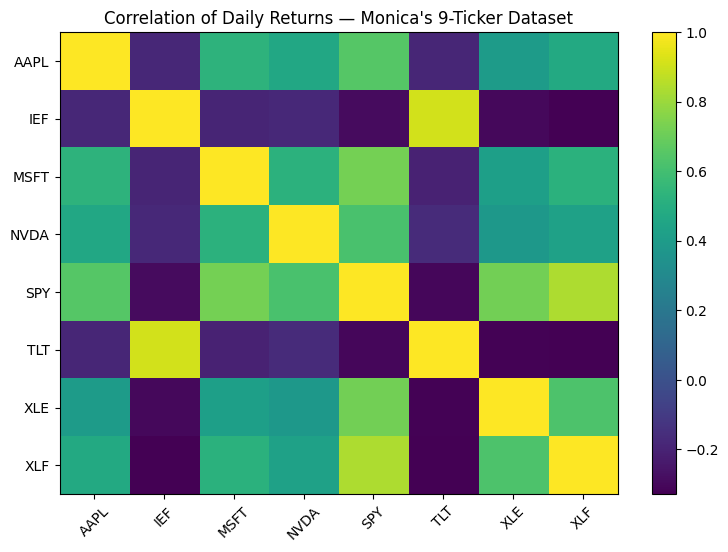

Ticker,AAPL,IEF,MSFT,NVDA,SPY,TLT,XLE,XLF
Ticker,,,,,,,,
AAPL,1.00,-0.18,0.53,0.47,0.65,-0.18,0.40,0.48
IEF,-0.18,1.00,-0.19,-0.18,-0.29,0.91,-0.30,-0.32
MSFT,0.53,-0.19,1.00,0.52,0.72,-0.20,0.42,0.52
NVDA,0.47,-0.18,0.52,1.00,0.62,-0.17,0.38,0.43
SPY,0.65,-0.29,0.72,0.62,1.00,-0.31,0.72,0.84
TLT,-0.18,0.91,-0.20,-0.17,-0.31,1.00,-0.32,-0.33
XLE,0.40,-0.30,0.42,0.38,0.72,-0.32,1.00,0.63
XLF,0.48,-0.32,0.52,0.43,0.84,-0.33,0.63,1.00


In [6]:
import matplotlib.pyplot as plt

correlation_matrix = daily_returns.corr()

plt.figure(figsize=(9, 6))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title("Correlation of Daily Returns — Monica's 9-Ticker Dataset")
plt.savefig("correlation_heatmap_monica.png", dpi=150, bbox_inches="tight")
plt.show()

correlation_matrix.round(2)